# DVD Rental Store Analysis — SQL & SQLite
## York University — Big Data Analytics Certificate (2024)

**Author:** Lalita  
**Tools:** Python, SQLite, Pandas, Matplotlib, Seaborn  
**Database:** SQLite Sakila Sample Database (16 tables)  

---

## Project Overview
This project analyzes a DVD rental store database using 
complex SQL JOINs across 6 tables to identify top performing 
films, most valuable customers and highest revenue categories.

## Key Findings
| Insight | Result |
|---|---|
| Top Rented Film | BUCKET BROTHERHOOD — 34 rentals |
| Top Customer | ELEANOR HUNT — 46 rentals |
| Highest Revenue Category | Sports — $5,314.21 |
| SQL Tables Used | 6 tables with complex JOINs |

## SQL Queries Used
- Complex JOINs across film, inventory, rental, payment tables
- GROUP BY and ORDER BY for aggregation
- COUNT and SUM for business metrics

## Conclusion
SQL analysis revealed Sports as highest revenue category
and identified top customers and films to support
data driven business decisions for the rental store.

---
🔗 **Kaggle Profile:** kaggle.com/lalitacanada  
🎓 **York University — Big Data Analytics (2024)**

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to SQLite database
conn = sqlite3.connect('/kaggle/input/datasets/atanaskanev/sqlite-sakila-sample-database/sqlite-sakila.db')

# Show all tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in database:")
print(tables)

Tables in database:
             name
0           actor
1         country
2            city
3         address
4        language
5        category
6        customer
7            film
8      film_actor
9   film_category
10      film_text
11      inventory
12          staff
13          store
14        payment
15         rental


In [2]:
# Query 1 — Top 10 most rented films
query1 = """
SELECT f.title, 
       COUNT(r.rental_id) as total_rentals
FROM film f
JOIN inventory i ON f.film_id = i.film_id
JOIN rental r ON i.inventory_id = r.inventory_id
GROUP BY f.title
ORDER BY total_rentals DESC
LIMIT 10
"""
top_films = pd.read_sql_query(query1, conn)
print("Top 10 Most Rented Films:")
print(top_films)

Top 10 Most Rented Films:
                 title  total_rentals
0   BUCKET BROTHERHOOD             34
1     ROCKETEER MOTHER             33
2        SCALAWAG DUCK             32
3  RIDGEMONT SUBMARINE             32
4       JUGGLER HARDLY             32
5       GRIT CLOCKWORK             32
6       FORWARD TEMPLE             32
7            ZORRO ARK             31
8            WIFE TURN             31
9       TIMBERLAND SKY             31


In [3]:
# Query 2 — Top 10 customers by rentals
query2 = """
SELECT c.first_name || ' ' || c.last_name as customer_name,
       COUNT(r.rental_id) as total_rentals,
       SUM(p.amount) as total_spent
FROM customer c
JOIN rental r ON c.customer_id = r.customer_id
JOIN payment p ON r.rental_id = p.rental_id
GROUP BY c.customer_id
ORDER BY total_rentals DESC
LIMIT 10
"""
top_customers = pd.read_sql_query(query2, conn)
print("Top 10 Customers by Rentals:")
print(top_customers)

Top 10 Customers by Rentals:
    customer_name  total_rentals  total_spent
0    ELEANOR HUNT             46       216.54
1       KARL SEAL             45       221.55
2     MARCIA DEAN             42       175.58
3      CLARA SHAW             42       195.58
4   TAMMY SANDERS             41       155.59
5     WESLEY BULL             40       177.60
6      SUE PETERS             40       154.60
7        TIM CARY             39       175.61
8   MARION SNYDER             39       194.61
9  RHONDA KENNEDY             39       194.61


In [4]:
# Query 3 — Revenue by film category
query3 = """
SELECT c.name as category,
       COUNT(r.rental_id) as total_rentals,
       SUM(p.amount) as total_revenue
FROM category c
JOIN film_category fc ON c.category_id = fc.category_id
JOIN film f ON fc.film_id = f.film_id
JOIN inventory i ON f.film_id = i.film_id
JOIN rental r ON i.inventory_id = r.inventory_id
JOIN payment p ON r.rental_id = p.rental_id
GROUP BY c.name
ORDER BY total_revenue DESC
"""
category_revenue = pd.read_sql_query(query3, conn)
print("Revenue by Film Category:")
print(category_revenue)

Revenue by Film Category:
       category  total_rentals  total_revenue
0        Sports           1179        5314.21
1        Sci-Fi           1101        4756.98
2     Animation           1166        4656.30
3         Drama           1060        4587.39
4        Comedy            941        4383.58
5        Action           1112        4375.85
6           New            940        4351.62
7         Games            969        4281.33
8       Foreign           1033        4270.67
9        Family           1096        4226.07
10  Documentary           1050        4217.52
11       Horror            846        3722.54
12     Children            945        3655.55
13     Classics            939        3639.59
14       Travel            837        3549.64
15        Music            830        3417.72


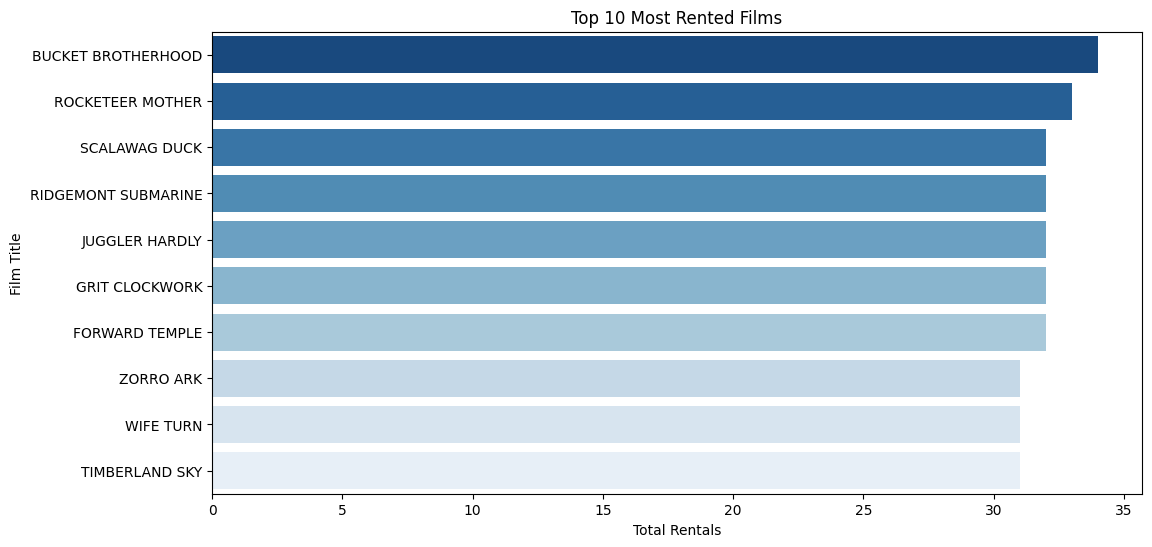

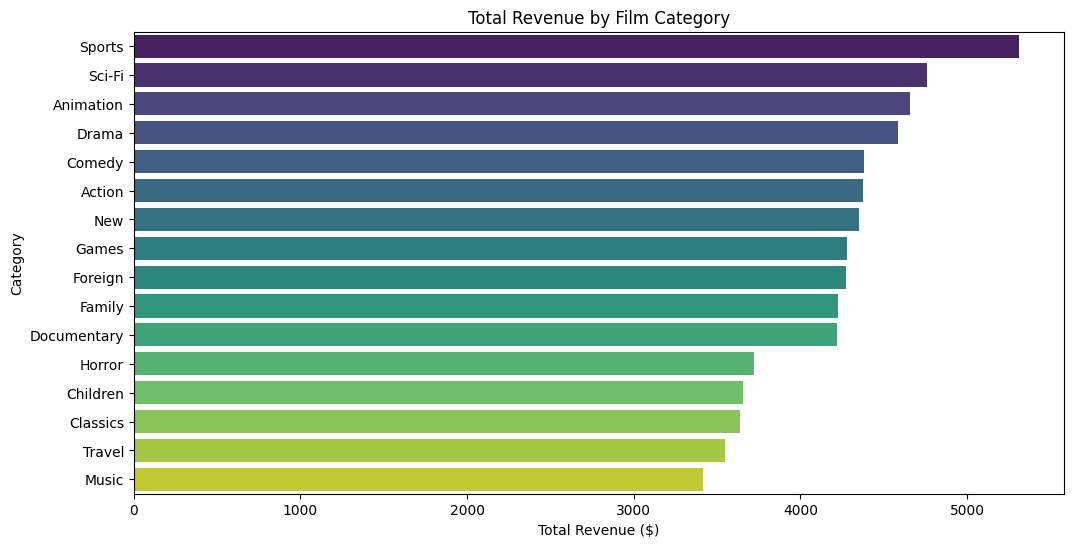

In [5]:
# Visualization 1 — Top 10 Most Rented Films
plt.figure(figsize=(12,6))
sns.barplot(data=top_films, 
            x='total_rentals', 
            y='title',
            hue='title',
            legend=False,
            palette='Blues_r')
plt.title('Top 10 Most Rented Films')
plt.xlabel('Total Rentals')
plt.ylabel('Film Title')
plt.show()

# Visualization 2 — Revenue by Category
plt.figure(figsize=(12,6))
sns.barplot(data=category_revenue,
            x='total_revenue',
            y='category',
            hue='category',
            legend=False,
            palette='viridis')
plt.title('Total Revenue by Film Category')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.show()

In [6]:
print("=" * 50)
print("KEY INSIGHTS — DVD Rental Store Analysis")
print("=" * 50)

print("\n📊 Database Overview:")
print("Database: SQLite Sakila Sample Database")
print("Tables analyzed: film, customer, rental,")
print("                 payment, category, inventory")

print("\n🎬 Top Rented Film:")
print(f"  {top_films.iloc[0]['title']} — {top_films.iloc[0]['total_rentals']} rentals")

print("\n👤 Top Customer:")
print(f"  {top_customers.iloc[0]['customer_name']}")
print(f"  Rentals: {top_customers.iloc[0]['total_rentals']}")
print(f"  Total Spent: ${top_customers.iloc[0]['total_spent']:.2f}")

print("\n💰 Top Revenue Category:")
print(f"  {category_revenue.iloc[0]['category']}")
print(f"  Revenue: ${category_revenue.iloc[0]['total_revenue']:.2f}")
print(f"  Rentals: {category_revenue.iloc[0]['total_rentals']}")

print("\n💡 Key Findings:")
print("1. Sports generates highest revenue — $5,314")
print("2. BUCKET BROTHERHOOD is most rented film")
print("3. ELEANOR HUNT is top customer — 46 rentals")
print("4. Complex SQL JOINs across 6 tables used")

print("\n✅ Conclusion:")
print("SQL analysis of DVD rental database revealed")
print("key business insights on top performing films,")
print("most valuable customers and highest revenue")
print("categories to support business decisions.")

conn.close()

KEY INSIGHTS — DVD Rental Store Analysis

📊 Database Overview:
Database: SQLite Sakila Sample Database
Tables analyzed: film, customer, rental,
                 payment, category, inventory

🎬 Top Rented Film:
  BUCKET BROTHERHOOD — 34 rentals

👤 Top Customer:
  ELEANOR HUNT
  Rentals: 46
  Total Spent: $216.54

💰 Top Revenue Category:
  Sports
  Revenue: $5314.21
  Rentals: 1179

💡 Key Findings:
1. Sports generates highest revenue — $5,314
2. BUCKET BROTHERHOOD is most rented film
3. ELEANOR HUNT is top customer — 46 rentals
4. Complex SQL JOINs across 6 tables used

✅ Conclusion:
SQL analysis of DVD rental database revealed
key business insights on top performing films,
most valuable customers and highest revenue
categories to support business decisions.
